In [105]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [106]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = '.' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
# 2. DATASET CLASS (The NPZ Loader)

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        #Normalization
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [ ]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [ ]:
# ==========================================
# 4. COMMON MODEL UTILITIES
# ==========================================

INPUT_SIZE = 784  # 28x28 flattened


def print_model_size(model, name="Model"):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{name} Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3_000_000:
        print("  ⚠️  WARNING: Over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")
    return total_params

# ==========================================
# TRAINING & EVALUATION UTILITIES
# ==========================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss   = criterion(logits, y)
        total_loss += loss.item() * X.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, label_smoothing= 0,
                num_epochs=EPOCHS, lr=1e-3, weight_decay=0,
                model_name="model", use_scheduler=None):
    """
    Full training loop with history tracking.
    Returns history dict with loss/acc curves.
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr,
            steps_per_epoch=len(train_loader),
            epochs=num_epochs
        )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n{'='*50}")
    print(f"  Training: {model_name}")
    print(f"{'='*50}")

    best_val_acc = 0.0
    best_state   = None

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        if scheduler:
            scheduler.step()  # OneCycleLR steps per batch; here we step per epoch for simplicity
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f"Epoch [{epoch:>2}/{num_epochs}]  "
              f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc*100:.2f}%  "
              f"Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc*100:.2f}%")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    # Restore best weights
    if best_state:
        model.load_state_dict(best_state)
        torch.save(best_state, f"{model_name}_best.pth")
        print(f"\n✅ Best Val Acc: {best_val_acc*100:.2f}% — weights saved to '{model_name}_best.pth'")

    return history


def plot_history(histories, model_names):
    """Plot training/validation loss and accuracy curves for multiple models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['tab:blue', 'tab:orange', 'tab:green']

    for i, (hist, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(hist['train_loss']) + 1)
        c = colors[i % len(colors)]

        axes[0].plot(epochs, hist['train_loss'], linestyle='--', color=c, alpha=0.7, label=f"{name} Train")
        axes[0].plot(epochs, hist['val_loss'],   linestyle='-',  color=c,           label=f"{name} Val")

        axes[1].plot(epochs, [a*100 for a in hist['train_acc']], linestyle='--', color=c, alpha=0.7, label=f"{name} Train")
        axes[1].plot(epochs, [a*100 for a in hist['val_acc']],   linestyle='-',  color=c,           label=f"{name} Val")

    axes[0].set_title('Loss Curves');  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[1].set_title('Accuracy Curves'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    for ax in axes:
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Training Comparison: Pancake vs Tower vs Champion', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved training_curves.png")


### Part A

In [ ]:
# ==========================================
# PART A: THE PANCAKE (Wide & Shallow)
# 2 hidden layers, high neuron count
# ==========================================
class PancakeMLP(nn.Module):
    """Shallow but wide MLP — Part A."""
    def __init__(self, input_size=INPUT_SIZE, num_classes=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            #nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            #nn.Dropout(0.40),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.net(x)


pancake_model  = PancakeMLP(num_classes=NUM_CLASSES).to(DEVICE)
print_model_size(pancake_model)




Model Statistics:
  Total Parameters: 1,336,335
  ✅ Parameter count is within limits.


1336335

In [139]:
# ==========================================
# PART A: TRAIN PANCAKE (Wide & Shallow)
# ==========================================

PANCAKE_EPOCHS = 20

pancake_model = PancakeMLP(num_classes=NUM_CLASSES).to(DEVICE)
history_pancake = train_model(
    pancake_model, train_loader, val_loader,
    num_epochs=PANCAKE_EPOCHS, lr=1e-3, weight_decay=0,
    model_name="pancake",
    use_scheduler = False,
    label_smoothing = 0.0
)


  Training: pancake


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [ 1/20]  Train Loss: 1.1377  Train Acc: 62.76%  Val Loss: 0.9416  Val Acc: 69.31%
Epoch [ 2/20]  Train Loss: 0.8034  Train Acc: 73.59%  Val Loss: 0.8158  Val Acc: 73.48%
Epoch [ 3/20]  Train Loss: 0.6570  Train Acc: 78.33%  Val Loss: 0.8006  Val Acc: 73.78%
Epoch [ 4/20]  Train Loss: 0.5425  Train Acc: 81.86%  Val Loss: 0.7678  Val Acc: 75.70%
Epoch [ 5/20]  Train Loss: 0.4503  Train Acc: 84.61%  Val Loss: 0.7776  Val Acc: 75.89%
Epoch [ 6/20]  Train Loss: 0.3661  Train Acc: 87.37%  Val Loss: 0.8347  Val Acc: 75.48%
Epoch [ 7/20]  Train Loss: 0.2923  Train Acc: 89.84%  Val Loss: 0.8971  Val Acc: 76.00%
Epoch [ 8/20]  Train Loss: 0.2353  Train Acc: 91.66%  Val Loss: 0.9436  Val Acc: 75.48%
Epoch [ 9/20]  Train Loss: 0.1812  Train Acc: 93.61%  Val Loss: 1.0461  Val Acc: 74.92%
Epoch [10/20]  Train Loss: 0.1365  Train Acc: 95.19%  Val Loss: 1.1397  Val Acc: 75.38%
Epoch [11/20]  Train Loss: 0.1099  Train Acc: 96.28%  Val Loss: 1.2875  Val Acc: 74.83%
Epoch [12/20]  Train Loss: 0.089

## Part B

In [ ]:

# ==========================================
# PART B: THE TOWER (Deep & Narrow)
# 7 hidden layers, low neuron count
# ==========================================
class TowerMLP(nn.Module):
    """Deep but narrow MLP — Part B."""
    def __init__(self, input_size=INPUT_SIZE, num_classes=15):
        super().__init__()
        self._init_weights() # Call _init_weights after it's defined
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 256),     # Layer 1
            nn.BatchNorm1d(256),
            nn.GELU(),
            #nn.Dropout(0.2),                # light dropout early

            nn.Linear(256, 256),            # Layer 2
            nn.BatchNorm1d(256),
            nn.GELU(),
            #nn.Dropout(0.2),

            nn.Linear(256, 256),            # Layer 3
            nn.BatchNorm1d(256),
            nn.GELU(),
            #nn.Dropout(0.2),

            nn.Linear(256, 128),            # Layer 4 (narrowing)
            nn.BatchNorm1d(128),
            nn.GELU(),
            #nn.Dropout(0.15),               # less dropout deeper

            nn.Linear(128, 128),            # Layer 5
            nn.BatchNorm1d(128),
            nn.GELU(),
            #nn.Dropout(0.15),

            nn.Linear(128, 128),            # Layer 6
            nn.BatchNorm1d(128),
            nn.GELU(),
            #nn.Dropout(0.1),                # very light at end

            nn.Linear(128, 128),            # Layer 7
            nn.BatchNorm1d(128),
            nn.GELU(),

            nn.Linear(128, num_classes)     # Output
        )

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

tower_model    = TowerMLP(num_classes=NUM_CLASSES).to(DEVICE)
print_model_size(tower_model)


Model Statistics:
  Total Parameters: 419,471
  ✅ Parameter count is within limits.


In [148]:
# ==========================================
# PART B: TRAIN TOWER (Deep & Narrow)
# ==========================================

TOWER_EPOCHS = 20

tower_model = TowerMLP(num_classes=NUM_CLASSES).to(DEVICE)
history_tower = train_model(
    tower_model, train_loader, val_loader,
    num_epochs=TOWER_EPOCHS, lr=1e-3, weight_decay=0,
    model_name="tower",
    use_scheduler = False,
    label_smoothing = 0.0
)


  Training: tower
Epoch [ 1/20]  Train Loss: 1.0787  Train Acc: 64.96%  Val Loss: 0.8580  Val Acc: 71.03%
Epoch [ 2/20]  Train Loss: 0.7889  Train Acc: 73.94%  Val Loss: 0.7933  Val Acc: 73.47%
Epoch [ 3/20]  Train Loss: 0.6819  Train Acc: 77.45%  Val Loss: 0.7380  Val Acc: 75.65%
Epoch [ 4/20]  Train Loss: 0.6038  Train Acc: 79.76%  Val Loss: 0.7331  Val Acc: 75.75%
Epoch [ 5/20]  Train Loss: 0.5400  Train Acc: 81.97%  Val Loss: 0.7442  Val Acc: 75.75%
Epoch [ 6/20]  Train Loss: 0.4831  Train Acc: 83.73%  Val Loss: 0.7310  Val Acc: 76.65%
Epoch [ 7/20]  Train Loss: 0.4274  Train Acc: 85.69%  Val Loss: 0.7280  Val Acc: 76.92%
Epoch [ 8/20]  Train Loss: 0.3857  Train Acc: 87.15%  Val Loss: 0.7642  Val Acc: 76.71%
Epoch [ 9/20]  Train Loss: 0.3409  Train Acc: 88.66%  Val Loss: 0.8075  Val Acc: 76.40%
Epoch [10/20]  Train Loss: 0.3134  Train Acc: 89.53%  Val Loss: 0.8602  Val Acc: 75.83%
Epoch [11/20]  Train Loss: 0.2788  Train Acc: 90.55%  Val Loss: 0.8682  Val Acc: 75.99%
Epoch [12/20]

## Part C

In [ ]:
# ==========================================
# PART C: THE CHAMPION (Best Architecture)
# Balanced depth/width + strong regularization

# ==========================================
class ChampionMLP(nn.Module):
    """Optimized MLP for leaderboard — Part C."""

    def __init__(self, input_size=INPUT_SIZE, num_classes=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            # Block 1
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            # Block 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),
            # Block 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.1),
            # Output
            nn.Linear(128, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


champion_model  = ChampionMLP(num_classes=NUM_CLASSES).to(DEVICE)
print_model_size(champion_model)


Model Statistics:
  Total Parameters: 569,871
  ✅ Parameter count is within limits.


569871

In [135]:
# ==========================================
# PART C: TRAIN CHAMPION (Best Model)
# ==========================================

CHAMPION_EPOCHS = 18  # Well under the 40-epoch limit

champion_model = ChampionMLP(num_classes=NUM_CLASSES).to(DEVICE)
history_champion = train_model(
    champion_model, train_loader, val_loader,
    num_epochs=CHAMPION_EPOCHS, lr=1e-2, weight_decay=2e-4,
    use_scheduler=True,
    model_name="champion"
)


  Training: champion
Epoch [ 1/18]  Train Loss: 1.3981  Train Acc: 55.12%  Val Loss: 0.9912  Val Acc: 67.80%
Epoch [ 2/18]  Train Loss: 1.0036  Train Acc: 67.06%  Val Loss: 0.8823  Val Acc: 70.58%
Epoch [ 3/18]  Train Loss: 0.8967  Train Acc: 70.35%  Val Loss: 0.8232  Val Acc: 72.78%
Epoch [ 4/18]  Train Loss: 0.8255  Train Acc: 72.61%  Val Loss: 0.7844  Val Acc: 74.24%
Epoch [ 5/18]  Train Loss: 0.7716  Train Acc: 74.41%  Val Loss: 0.7584  Val Acc: 74.89%
Epoch [ 6/18]  Train Loss: 0.7211  Train Acc: 75.95%  Val Loss: 0.7327  Val Acc: 75.73%
Epoch [ 7/18]  Train Loss: 0.6761  Train Acc: 77.48%  Val Loss: 0.7201  Val Acc: 76.38%
Epoch [ 8/18]  Train Loss: 0.6397  Train Acc: 78.52%  Val Loss: 0.7038  Val Acc: 76.88%
Epoch [ 9/18]  Train Loss: 0.6044  Train Acc: 79.94%  Val Loss: 0.6976  Val Acc: 77.25%
Epoch [10/18]  Train Loss: 0.5777  Train Acc: 80.57%  Val Loss: 0.6878  Val Acc: 77.62%
Epoch [11/18]  Train Loss: 0.5510  Train Acc: 81.46%  Val Loss: 0.6857  Val Acc: 77.95%
Epoch [12/

## Part D

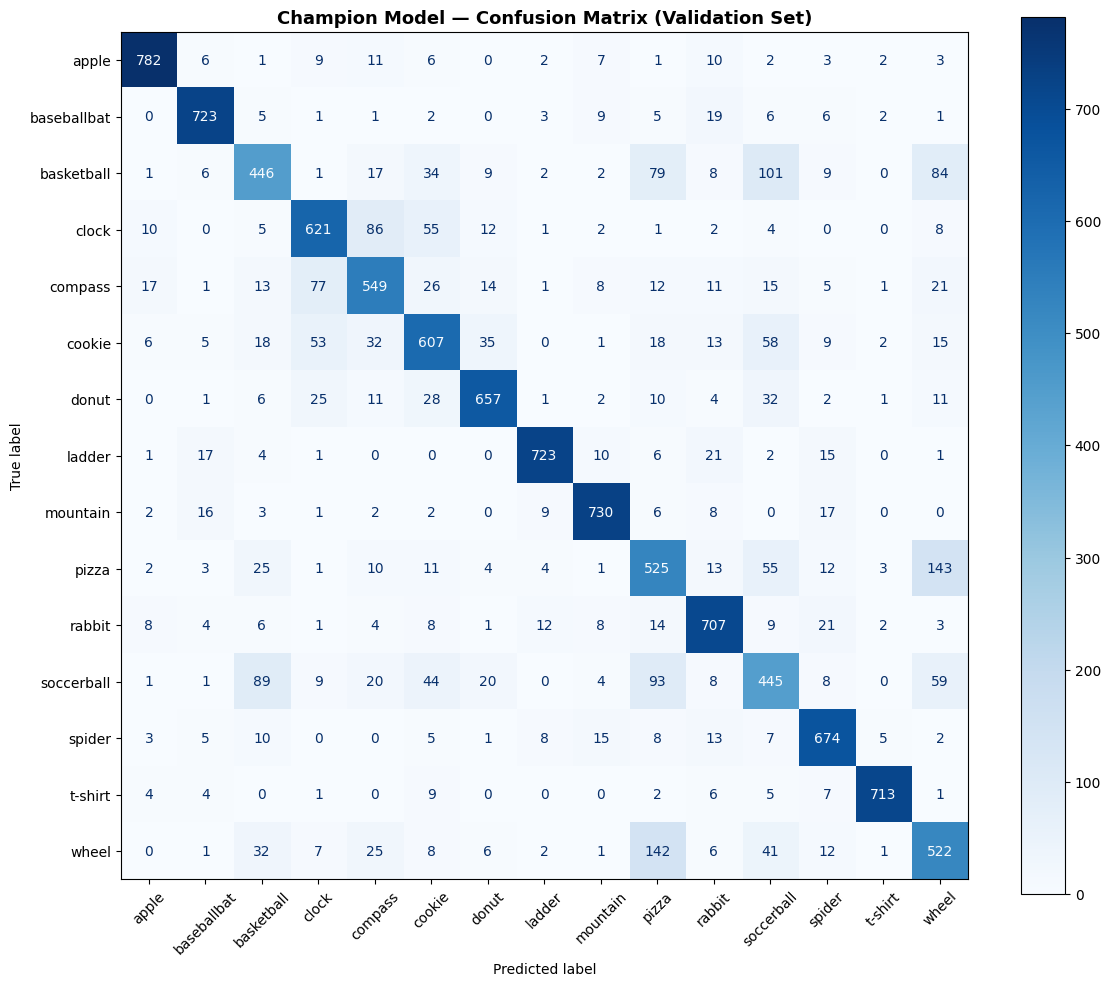

Saved confusion_matrix.png

Top Confused Pairs:
  'pizza' predicted as 'wheel' — 143 times
  'basketball' predicted as 'soccerball' — 101 times


In [ ]:
# ==========================================
# PART D: CONFUSION MATRIX ANALYSIS
# (Champion model on validation set)
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def get_all_preds_and_labels(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for X, y in loader:
        X = X.to(DEVICE)
        logits = model(X)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
    return np.array(all_preds), np.array(all_labels)


preds, labels = get_all_preds_and_labels(champion_model, val_loader)

cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
ax.set_title('Champion Model — Confusion Matrix (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrix.png")

# Identify top-2 most confused pairs 
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# Top 2 off-diagonal entries
flat_idx = np.argsort(cm_no_diag.ravel())[::-1][:4]
print("\nTop Confused Pairs:")
seen = set()
count = 0
for idx in flat_idx:
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    pair = tuple(sorted([i, j]))
    if pair not in seen:
        seen.add(pair)
        print(f"  '{CLASSES[i]}' predicted as '{CLASSES[j]}' — {cm_no_diag[i, j]} times")
        count += 1
    if count == 2:
        break

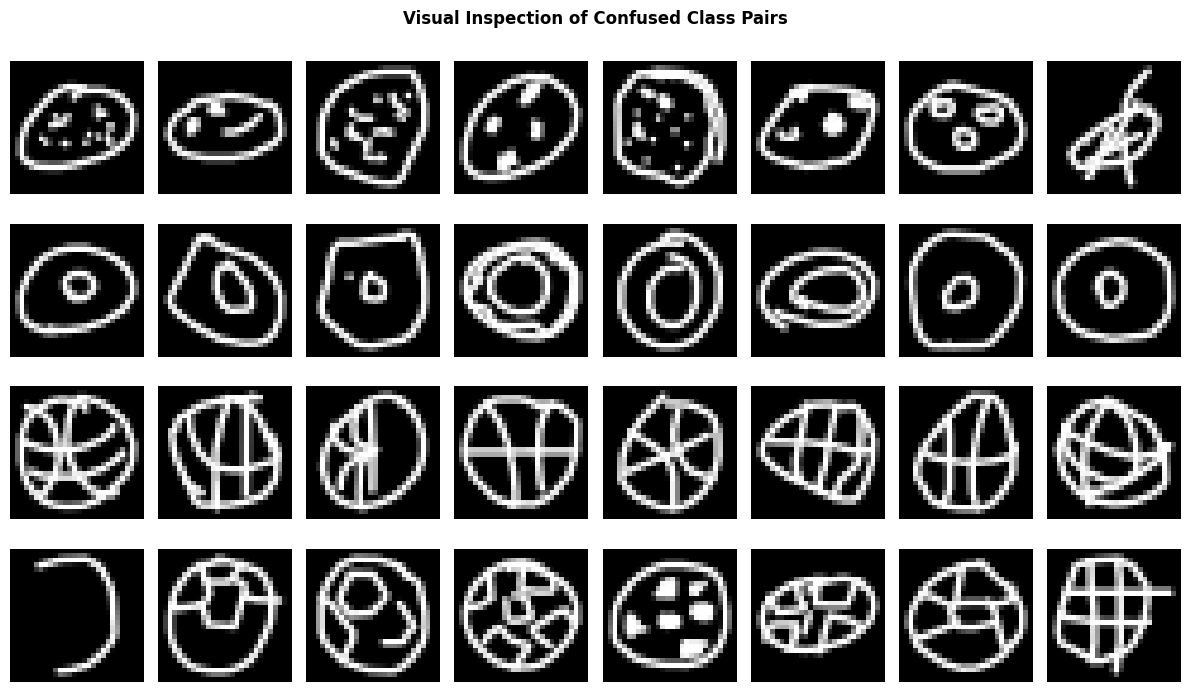

Saved confused_classes.png


In [143]:
# ==========================================
# PART D: VISUALIZE CONFUSED CLASS SAMPLES
# ==========================================

def show_class_samples(dataset, class_indices, class_names, n=8):
    """
    Show n random samples from each class in class_indices.
    dataset: the full_train_dataset (has .x and .y)
    """
    fig, axes = plt.subplots(len(class_indices), n, figsize=(n*1.5, len(class_indices)*1.8))
    if len(class_indices) == 1:
        axes = [axes]

    for row, cls_idx in enumerate(class_indices):
        mask = (full_train_dataset.y == cls_idx).numpy()
        indices = np.where(mask)[0]
        chosen  = np.random.choice(indices, size=min(n, len(indices)), replace=False)
        for col, idx in enumerate(chosen):
            img = full_train_dataset.x[idx].numpy()
            # Handle flat (784,) or (1,28,28) or (28,28)
            if img.ndim == 1:
                img = img.reshape(28, 28)
            elif img.ndim == 3:
                img = img.squeeze(0)
            axes[row][col].imshow(img, cmap='gray')
            axes[row][col].axis('off')
        axes[row][0].set_ylabel(class_names[cls_idx], fontsize=10, rotation=0,
                                 labelpad=50, va='center')

    plt.suptitle('Visual Inspection of Confused Class Pairs', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confused_classes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved confused_classes.png")


# Show the top 2 confused pairs
confused_indices = [CLASSES.index('cookie'), CLASSES.index('donut'),
                    CLASSES.index('basketball'), CLASSES.index('soccerball')]

show_class_samples(full_train_dataset, confused_indices, CLASSES)

# Part E

In [149]:
# ==========================================
# PART E: MODEL COMPARISON TABLE
# ==========================================

# Use same criterion as training
criterion = nn.CrossEntropyLoss()

# Explicitly set eval mode before evaluating
pancake_model.eval()
tower_model.eval()
champion_model.eval()

_, pancake_val_acc  = evaluate(pancake_model,  val_loader, criterion)
_, tower_val_acc    = evaluate(tower_model,    val_loader, criterion)
_, champion_val_acc = evaluate(champion_model, val_loader, criterion)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Retrieve final training accuracies
pancake_train_acc = history_pancake['train_acc'][-1]
tower_train_acc = history_tower['train_acc'][-1]
champion_train_acc = history_champion['train_acc'][-1]

print("\n" + "="*90)
print(f"{'Model':<15} {'Parameters':>15} {'Epochs':>8} {'Train Accuracy':>16} {'Val Accuracy':>14}")
print("-"*90)
print(f"{'Pancake (A)':<15} {count_params(pancake_model):>15,} {PANCAKE_EPOCHS:>8} {pancake_train_acc*100:>15.2f}% {pancake_val_acc*100:>13.2f}%")
print(f"{'Tower (B)':<15} {count_params(tower_model):>15,} {TOWER_EPOCHS:>8} {tower_train_acc*100:>15.2f}% {tower_val_acc*100:>13.2f}%")
print(f"{'Champion (C)':<15} {count_params(champion_model):>15,} {CHAMPION_EPOCHS:>8} {champion_train_acc*100:>15.2f}% {champion_val_acc*100:>13.2f}%")
print("="*90)


Model                Parameters   Epochs   Train Accuracy   Val Accuracy
------------------------------------------------------------------------------------------
Pancake (A)           1,336,335       20           98.06%         76.00%
Tower (B)               419,471       20           95.86%         76.92%
Champion (C)            569,871       18           86.39%         78.53%


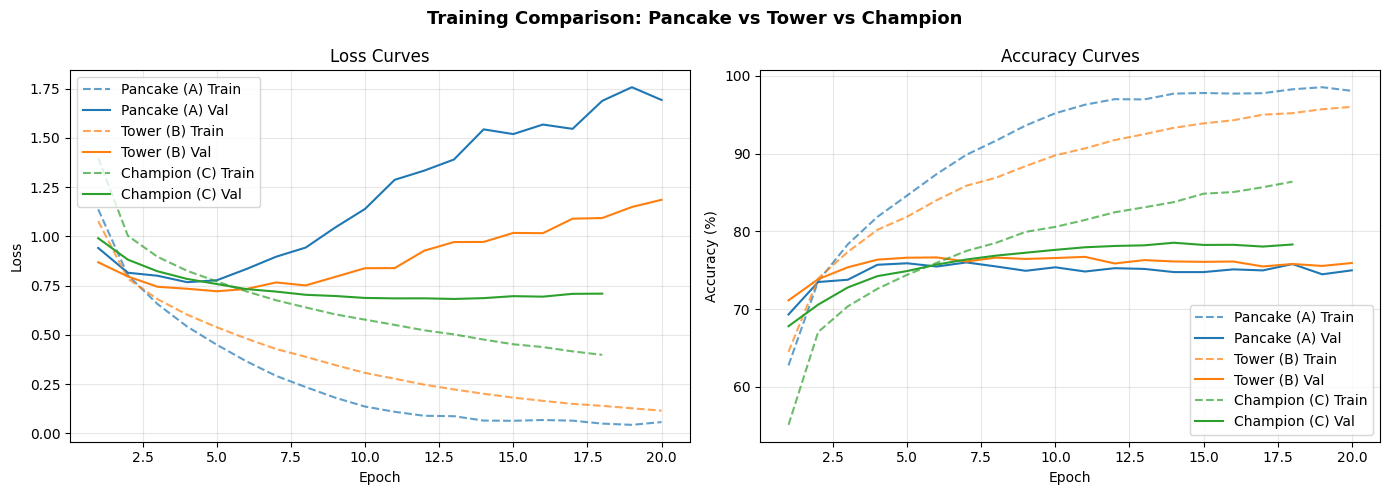

Saved training_curves.png


In [141]:
# ==========================================
# PART E: TRAINING CURVES COMPARISON
# ==========================================

plot_history(
    [history_pancake, history_tower, history_champion],
    ["Pancake (A)", "Tower (B)", "Champion (C)"]
)

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# INFERENCE & LEADERBOARD SUBMISSION
# BASED ON CHAMPION model
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)

test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

print("Running inference on test set...")

model = champion_model
predictions = get_predictions(model, test_loader)

submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")
print(f"   Total predictions: {len(predictions)}")


   GENERATING SUBMISSION FILE
Loading test data from ./quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.
   Total predictions: 15000


In [145]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 569,871
  ✅ Parameter count is within limits.
